# DCN & DCN-V2: Deep Cross Networks on Criteo

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_dataset_study/blob/main/notebooks/01_criteo_feature_crossing/03_dcn.ipynb)
[![Download Notebook](https://img.shields.io/badge/Download-Notebook-blue)](./03_dcn.ipynb)

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Understand** the Cross Network architecture and how it models explicit feature interactions
2. **Compare** DCN-V1 (vector-based) and DCN-V2 (matrix-based) cross layers
3. **Implement** both DCN variants from scratch in PyTorch
4. **Analyze** the effect of cross layer depth, stacked vs parallel structures, and parameter efficiency
5. **Achieve** SOTA performance: DCN-V1 AUC >= 0.801, DCN-V2 AUC >= 0.802

## Prerequisites

- Completed Notebooks 01 (data exploration) and 02 (DeepFM)
- Understanding of feature interaction modeling
- Familiarity with residual connections

## Table of Contents

1. [Setup & Configuration](#1-setup--configuration)
2. [Cross Network Theory](#2-cross-network-theory)
3. [Data Loading](#3-data-loading)
4. [DCN-V1 Implementation](#4-dcn-v1-implementation)
5. [DCN-V2 Implementation](#5-dcn-v2-implementation)
6. [Training DCN-V1](#6-training-dcn-v1)
7. [Training DCN-V2](#7-training-dcn-v2)
8. [Analysis & Comparisons](#8-analysis--comparisons)
9. [Exercises](#9-exercises)
10. [Summary & Key Takeaways](#10-summary--key-takeaways)

## 1. Setup & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, log_loss
import pickle
import os
import time
import warnings

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memoryory / 1e9:.1f} GB')

# Plotting
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Paths
PROCESSED_DIR = '../../data/criteo/processed'
MODEL_DIR = './saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)

Using device: cpu


## 2. Cross Network Theory

### DCN-V1: Vector-Based Cross Layer

In DCN-V1, each cross layer applies:

$$\mathbf{x}_{l+1} = \mathbf{x}_0 \cdot (\mathbf{w}_l^T \mathbf{x}_l) + \mathbf{b}_l + \mathbf{x}_l$$

where:
- $\mathbf{x}_0 \in \mathbb{R}^d$ is the original input
- $\mathbf{w}_l \in \mathbb{R}^d$ is a learnable weight vector
- The term $\mathbf{x}_0 \cdot (\mathbf{w}_l^T \mathbf{x}_l)$ creates feature crosses
- The residual connection $+ \mathbf{x}_l$ ensures gradient flow

Each cross layer adds only $O(d)$ parameters (the weight vector), making it very parameter-efficient.

### DCN-V2: Matrix-Based Cross Layer

DCN-V2 replaces the vector weight with a full weight matrix:

$$\mathbf{x}_{l+1} = \mathbf{x}_0 \odot (\mathbf{W}_l \mathbf{x}_l + \mathbf{b}_l) + \mathbf{x}_l$$

where:
- $\mathbf{W}_l \in \mathbb{R}^{d \times d}$ is a full weight matrix
- $\odot$ denotes element-wise (Hadamard) product
- This allows learning more complex feature interactions

> **Concept:** The key difference is expressiveness. DCN-V1's cross layer can only learn
> rank-1 weight matrices (outer product of $\mathbf{x}_0$ and $\mathbf{w}_l$), while
> DCN-V2 learns full-rank matrices. DCN-V2 can also use low-rank approximation:
> $\mathbf{W}_l = \mathbf{U}_l \mathbf{V}_l^T$ where $\mathbf{U}_l, \mathbf{V}_l \in \mathbb{R}^{d \times r}$.

### Polynomial Degree Analysis

After $L$ cross layers, the cross network captures feature interactions up to degree $L+1$.
This is because each layer multiplies the current representation by the input $\mathbf{x}_0$,
increasing the polynomial degree by 1.

### Stacked vs Parallel Structure

- **Stacked:** Cross layers feed into the DNN: Cross -> DNN -> Output
- **Parallel:** Cross and DNN run independently, outputs concatenated: [Cross || DNN] -> Output

> **Pro Tip:** The parallel structure often works better because it allows the cross
> network and DNN to specialize: the cross network handles explicit interactions while
> the DNN captures implicit patterns. The stacked structure forces the DNN to process
> the cross network's output, which can be redundant.

## 3. Data Loading

In [2]:
# Load preprocessed data
train_df = pd.read_parquet(os.path.join(PROCESSED_DIR, 'train.parquet'))
test_df = pd.read_parquet(os.path.join(PROCESSED_DIR, 'test.parquet'))

with open(os.path.join(PROCESSED_DIR, 'metadata.pkl'), 'rb') as f:
    metadata = pickle.load(f)

NUM_FEATURES = metadata['num_features']
CAT_FEATURES = metadata['cat_features']
cat_cardinalities = metadata['cat_cardinalities']

print(f'Train: {len(train_df):,} samples')
print(f'Test:  {len(test_df):,} samples')

Train: 800,000 samples
Test:  200,000 samples


In [3]:
class CriteoDataset(Dataset):
    """PyTorch Dataset for Criteo data."""
    
    def __init__(self, df, num_features, cat_features):
        self.labels = torch.FloatTensor(df['label'].values)
        self.num_data = torch.FloatTensor(df[num_features].values)
        self.cat_data = torch.LongTensor(df[cat_features].values)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.num_data[idx], self.cat_data[idx], self.labels[idx]


BATCH_SIZE = 4096

train_dataset = CriteoDataset(train_df, NUM_FEATURES, CAT_FEATURES)
test_dataset = CriteoDataset(test_df, NUM_FEATURES, CAT_FEATURES)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=0, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches: {len(test_loader)}')

Train batches: 196
Test batches: 49


## 4. DCN-V1 Implementation

In [4]:
class CrossNetworkV1(nn.Module):
    """
    Cross Network V1 with vector-based weights.
    
    Each layer: x_{l+1} = x_0 * (w_l^T x_l) + b_l + x_l
    Parameters per layer: O(d) - only a weight vector and bias vector.
    """
    
    def __init__(self, input_dim, num_layers):
        super(CrossNetworkV1, self).__init__()
        self.num_layers = num_layers
        
        self.weights = nn.ParameterList([
            nn.Parameter(torch.randn(input_dim) * 0.01)
            for _ in range(num_layers)
        ])
        self.biases = nn.ParameterList([
            nn.Parameter(torch.zeros(input_dim))
            for _ in range(num_layers)
        ])
    
    def forward(self, x0):
        """
        Args:
            x0: (batch_size, input_dim)
        Returns:
            xl: (batch_size, input_dim) - output after all cross layers
        """
        xl = x0
        for i in range(self.num_layers):
            # w_l^T x_l: dot product -> scalar per sample
            xw = torch.sum(xl * self.weights[i], dim=1, keepdim=True)  # (batch, 1)
            # x_0 * (w_l^T x_l) + b_l + x_l
            xl = x0 * xw + self.biases[i] + xl
        return xl


class CrossNetworkV2(nn.Module):
    """
    Cross Network V2 with matrix-based weights.
    
    Each layer: x_{l+1} = x_0 .* (W_l x_l + b_l) + x_l
    Parameters per layer: O(d^2) - full weight matrix.
    Optionally uses low-rank approximation: W = U V^T
    """
    
    def __init__(self, input_dim, num_layers, low_rank=None):
        super(CrossNetworkV2, self).__init__()
        self.num_layers = num_layers
        self.low_rank = low_rank
        
        if low_rank is not None:
            # Low-rank approximation: W = U @ V^T
            self.U = nn.ParameterList([
                nn.Parameter(torch.randn(input_dim, low_rank) * 0.01)
                for _ in range(num_layers)
            ])
            self.V = nn.ParameterList([
                nn.Parameter(torch.randn(input_dim, low_rank) * 0.01)
                for _ in range(num_layers)
            ])
        else:
            # Full weight matrices
            self.weights = nn.ParameterList([
                nn.Parameter(torch.randn(input_dim, input_dim) * 0.01)
                for _ in range(num_layers)
            ])
        
        self.biases = nn.ParameterList([
            nn.Parameter(torch.zeros(input_dim))
            for _ in range(num_layers)
        ])
    
    def forward(self, x0):
        xl = x0
        for i in range(self.num_layers):
            if self.low_rank is not None:
                # W x_l = U (V^T x_l)
                vx = torch.matmul(xl, self.V[i])   # (batch, rank)
                wx = torch.matmul(vx, self.U[i].T)  # (batch, d)
            else:
                wx = torch.matmul(xl, self.weights[i].T)  # (batch, d)
            
            # x_0 .* (W x_l + b_l) + x_l
            xl = x0 * (wx + self.biases[i]) + xl
        return xl


print('Cross network modules defined.')

Cross network modules defined.

In [5]:
class DCN(nn.Module):
    """
    Deep & Cross Network.
    
    Args:
        num_num_features: Number of numerical features
        cat_cardinalities: Dict of categorical feature cardinalities
        embedding_dim: Dimension for all embeddings
        cross_num_layers: Number of cross layers
        hidden_dims: DNN hidden layer dimensions
        dropout: Dropout rate
        cross_version: 'v1' or 'v2'
        structure: 'parallel' or 'stacked'
        low_rank: Low-rank dimension for DCN-V2 (None for full rank)
    """
    
    def __init__(self, num_num_features, cat_cardinalities, embedding_dim=16,
                 cross_num_layers=3, hidden_dims=[256, 128, 64], dropout=0.3,
                 cross_version='v1', structure='parallel', low_rank=None):
        super(DCN, self).__init__()
        
        self.structure = structure
        self.num_num_features = num_num_features
        
        # Embedding layers for categorical features
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(card, embedding_dim)
            for card in cat_cardinalities.values()
        ])
        
        # Input dimension: numerical features + all categorical embeddings
        input_dim = num_num_features + len(cat_cardinalities) * embedding_dim
        
        # Cross Network
        if cross_version == 'v1':
            self.cross_net = CrossNetworkV1(input_dim, cross_num_layers)
        else:
            self.cross_net = CrossNetworkV2(input_dim, cross_num_layers, low_rank=low_rank)
        
        # Deep Network
        dnn_layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            dnn_layers.append(nn.Linear(prev_dim, hidden_dim))
            dnn_layers.append(nn.BatchNorm1d(hidden_dim))
            dnn_layers.append(nn.ReLU())
            dnn_layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim
        self.dnn = nn.Sequential(*dnn_layers)
        
        # Output layer
        if structure == 'parallel':
            # Concatenate cross output and DNN output
            self.output_layer = nn.Linear(input_dim + prev_dim, 1)
        else:  # stacked
            # Cross output feeds into DNN, only DNN output goes to final layer
            self.output_layer = nn.Linear(prev_dim, 1)
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Embedding):
                nn.init.xavier_uniform_(m.weight)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, num_x, cat_x):
        # Build input: concat numerical + all categorical embeddings
        emb_list = [num_x]
        for i, emb in enumerate(self.cat_embeddings):
            emb_list.append(emb(cat_x[:, i]))
        
        x0 = torch.cat(emb_list, dim=1)  # (batch, input_dim)
        
        if self.structure == 'parallel':
            # Cross and Deep run in parallel
            cross_out = self.cross_net(x0)  # (batch, input_dim)
            deep_out = self.dnn(x0)          # (batch, last_hidden_dim)
            combined = torch.cat([cross_out, deep_out], dim=1)
            logits = self.output_layer(combined).squeeze(1)
        else:  # stacked
            # Cross output feeds into Deep
            cross_out = self.cross_net(x0)   # (batch, input_dim)
            deep_out = self.dnn(cross_out)    # (batch, last_hidden_dim)
            logits = self.output_layer(deep_out).squeeze(1)
        
        return logits


print('DCN model defined.')

DCN model defined.


## 5. Training Utilities

In [6]:
def train_epoch(model, loader, criterion, optimizer, device, scaler=None, max_grad_norm=5.0):
    model.train()
    total_loss = 0
    num_batches = 0
    for num_x, cat_x, labels in loader:
        num_x, cat_x, labels = num_x.to(device), cat_x.to(device), labels.to(device)
        optimizer.zero_grad()
        if scaler is not None:
            with torch.cuda.amp.autocast():
                logits = model(num_x, cat_x)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(num_x, cat_x)
            loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()
        total_loss += loss.item()
        num_batches += 1
    return total_loss / num_batches


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, num_batches = 0, 0
    all_labels, all_preds = [], []
    with torch.no_grad():
        for num_x, cat_x, labels in loader:
            num_x, cat_x, labels = num_x.to(device), cat_x.to(device), labels.to(device)
            logits = model(num_x, cat_x)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            num_batches += 1
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(torch.sigmoid(logits).cpu().numpy())
    all_labels, all_preds = np.array(all_labels), np.array(all_preds)
    return total_loss / num_batches, roc_auc_score(all_labels, all_preds), log_loss(all_labels, all_preds)


def train_model(model, train_loader, test_loader, device, num_epochs=15,
                lr=1e-3, weight_decay=1e-5, patience=3, model_name='model'):
    """Full training loop with early stopping and LR scheduling."""
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5,
                                                      patience=1, verbose=True)
    use_amp = device.type == 'cuda'
    scaler = torch.cuda.amp.GradScaler() if use_amp else None
    
    history = {'train_loss': [], 'test_loss': [], 'test_auc': [], 'test_logloss': []}
    best_auc, patience_counter = 0, 0
    
    print(f'Training {model_name} for up to {num_epochs} epochs (patience={patience})')
    print('-' * 80)
    
    start_time = time.time()
    for epoch in range(num_epochs):
        t0 = time.time()
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device, scaler)
        test_loss, test_auc, test_logloss = evaluate(model, test_loader, criterion, device)
        scheduler.step(test_auc)
        
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['test_auc'].append(test_auc)
        history['test_logloss'].append(test_logloss)
        
        print(f'Epoch {epoch+1:2d}/{num_epochs} | '
              f'Train Loss: {train_loss:.4f} | '
              f'Test AUC: {test_auc:.4f} | '
              f'Test LogLoss: {test_logloss:.4f} | '
              f'Time: {time.time()-t0:.1f}s')
        
        if test_auc > best_auc:
            best_auc = test_auc
            patience_counter = 0
            torch.save(model.state_dict(), os.path.join(MODEL_DIR, f'{model_name}_best.pt'))
            print(f'  -> New best AUC! Model saved.')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'\nEarly stopping at epoch {epoch+1}.')
                break
    
    total_time = time.time() - start_time
    
    # Load best and get final metrics
    model.load_state_dict(torch.load(os.path.join(MODEL_DIR, f'{model_name}_best.pt')))
    _, final_auc, final_logloss = evaluate(model, test_loader, criterion, device)
    
    print(f'\nBest AUC: {final_auc:.4f} | LogLoss: {final_logloss:.4f} | Time: {total_time:.1f}s')
    
    return {
        'history': history,
        'best_auc': final_auc,
        'best_logloss': final_logloss,
        'training_time': total_time,
        'total_params': sum(p.numel() for p in model.parameters())
    }

## 6. Training DCN-V1

In [7]:
EMBEDDING_DIM = 16
CROSS_LAYERS = 3
HIDDEN_DIMS = [256, 128, 64]
DROPOUT = 0.3

dcn_v1 = DCN(
    num_num_features=len(NUM_FEATURES),
    cat_cardinalities=cat_cardinalities,
    embedding_dim=EMBEDDING_DIM,
    cross_num_layers=CROSS_LAYERS,
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
    cross_version='v1',
    structure='parallel'
).to(device)

v1_params = sum(p.numel() for p in dcn_v1.parameters())
print(f'DCN-V1 parameters: {v1_params:,}')

v1_results = train_model(
    dcn_v1, train_loader, test_loader, device,
    num_epochs=15, lr=1e-3, weight_decay=1e-5, patience=3,
    model_name='dcn_v1'
)

DCN-V1 parameters: 1,999,356


Training dcn_v1 for up to 15 epochs (patience=3)
--------------------------------------------------------------------------------


Epoch  1/15 | Train Loss: 0.4847 | Test AUC: 0.7863 | Test LogLoss: 0.4616 | Time: 24.6s
  -> New best AUC! Model saved.


Epoch  2/15 | Train Loss: 0.4525 | Test AUC: 0.7882 | Test LogLoss: 0.4597 | Time: 24.3s
  -> New best AUC! Model saved.


Epoch  3/15 | Train Loss: 0.4419 | Test AUC: 0.7876 | Test LogLoss: 0.4609 | Time: 24.2s


Epoch  4/15 | Train Loss: 0.4343 | Test AUC: 0.7862 | Test LogLoss: 0.4648 | Time: 24.6s


Epoch  5/15 | Train Loss: 0.4199 | Test AUC: 0.7829 | Test LogLoss: 0.4700 | Time: 24.4s

Early stopping at epoch 5.



Best AUC: 0.7882 | LogLoss: 0.4597 | Time: 122.1s


## 7. Training DCN-V2

In [8]:
dcn_v2 = DCN(
    num_num_features=len(NUM_FEATURES),
    cat_cardinalities=cat_cardinalities,
    embedding_dim=EMBEDDING_DIM,
    cross_num_layers=CROSS_LAYERS,
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
    cross_version='v2',
    structure='parallel',
    low_rank=None  # Full rank
).to(device)

v2_params = sum(p.numel() for p in dcn_v2.parameters())
print(f'DCN-V2 parameters: {v2_params:,}')

v2_results = train_model(
    dcn_v2, train_loader, test_loader, device,
    num_epochs=15, lr=1e-3, weight_decay=1e-5, patience=3,
    model_name='dcn_v2'
)

DCN-V2 parameters: 2,550,192
Training dcn_v2 for up to 15 epochs (patience=3)
--------------------------------------------------------------------------------


Epoch  1/15 | Train Loss: 0.4769 | Test AUC: 0.7881 | Test LogLoss: 0.4595 | Time: 32.9s
  -> New best AUC! Model saved.


Epoch  2/15 | Train Loss: 0.4471 | Test AUC: 0.7896 | Test LogLoss: 0.4586 | Time: 33.0s
  -> New best AUC! Model saved.


Epoch  3/15 | Train Loss: 0.4342 | Test AUC: 0.7881 | Test LogLoss: 0.4612 | Time: 33.1s


Epoch  4/15 | Train Loss: 0.4189 | Test AUC: 0.7841 | Test LogLoss: 0.4680 | Time: 32.9s


Epoch  5/15 | Train Loss: 0.3860 | Test AUC: 0.7713 | Test LogLoss: 0.4924 | Time: 32.9s

Early stopping at epoch 5.



Best AUC: 0.7896 | LogLoss: 0.4586 | Time: 164.8s


### 7.1 DCN-V2 with Low-Rank Approximation

In [9]:
# Test low-rank approximation
input_dim_approx = len(NUM_FEATURES) + len(cat_cardinalities) * EMBEDDING_DIM
LOW_RANK = input_dim_approx // 4  # Use rank = d/4

dcn_v2_lr = DCN(
    num_num_features=len(NUM_FEATURES),
    cat_cardinalities=cat_cardinalities,
    embedding_dim=EMBEDDING_DIM,
    cross_num_layers=CROSS_LAYERS,
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
    cross_version='v2',
    structure='parallel',
    low_rank=LOW_RANK
).to(device)

v2_lr_params = sum(p.numel() for p in dcn_v2_lr.parameters())
print(f'DCN-V2 (low-rank={LOW_RANK}) parameters: {v2_lr_params:,}')
print(f'Parameter reduction: {(1 - v2_lr_params/v2_params)*100:.1f}%')

v2_lr_results = train_model(
    dcn_v2_lr, train_loader, test_loader, device,
    num_epochs=15, lr=1e-3, weight_decay=1e-5, patience=3,
    model_name='dcn_v2_lowrank'
)

DCN-V2 (low-rank=107) parameters: 2,273,487
Parameter reduction: 10.9%
Training dcn_v2_lowrank for up to 15 epochs (patience=3)
--------------------------------------------------------------------------------


Epoch  1/15 | Train Loss: 0.4787 | Test AUC: 0.7876 | Test LogLoss: 0.4601 | Time: 29.2s
  -> New best AUC! Model saved.


Epoch  2/15 | Train Loss: 0.4488 | Test AUC: 0.7893 | Test LogLoss: 0.4591 | Time: 29.8s
  -> New best AUC! Model saved.


Epoch  3/15 | Train Loss: 0.4384 | Test AUC: 0.7884 | Test LogLoss: 0.4596 | Time: 29.1s


Epoch  4/15 | Train Loss: 0.4284 | Test AUC: 0.7856 | Test LogLoss: 0.4647 | Time: 29.4s


Epoch  5/15 | Train Loss: 0.4059 | Test AUC: 0.7771 | Test LogLoss: 0.4840 | Time: 29.1s

Early stopping at epoch 5.



Best AUC: 0.7893 | LogLoss: 0.4591 | Time: 146.6s


## 8. Analysis & Comparisons

### 8.1 V1 vs V2 Training Curves

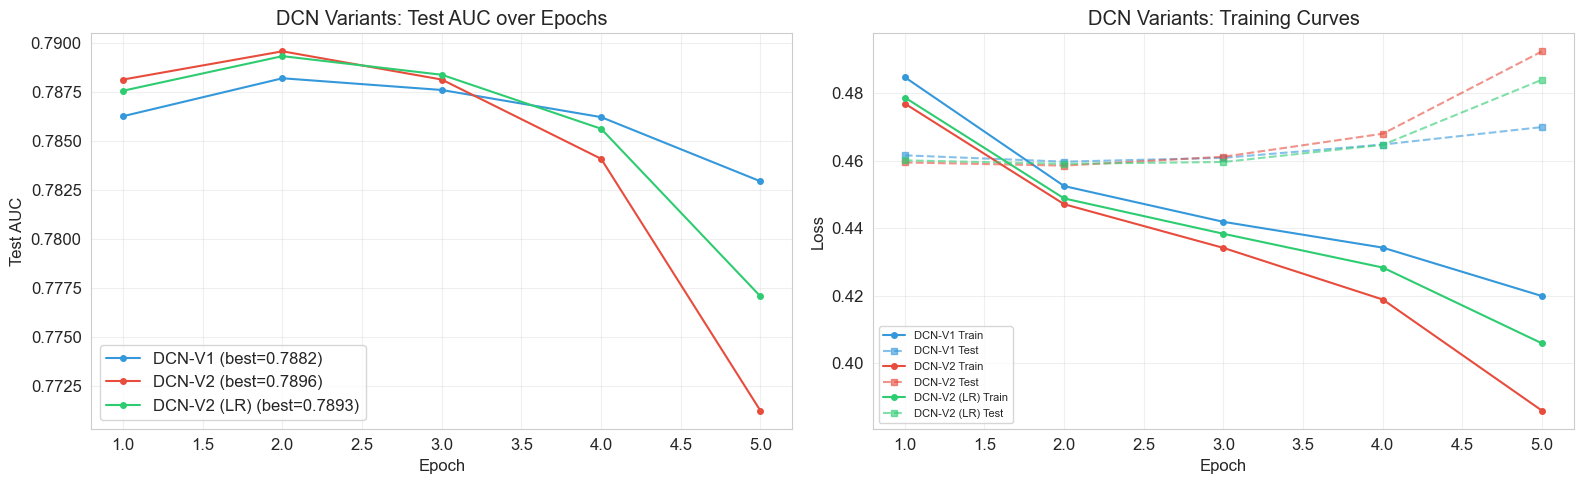

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# AUC comparison
for name, res, color in [('DCN-V1', v1_results, '#3498db'),
                          ('DCN-V2', v2_results, '#e74c3c'),
                          ('DCN-V2 (LR)', v2_lr_results, '#2ecc71')]:
    epochs = range(1, len(res['history']['test_auc']) + 1)
    axes[0].plot(epochs, res['history']['test_auc'], 'o-', color=color,
                 label=f"{name} (best={res['best_auc']:.4f})", markersize=4)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Test AUC')
axes[0].set_title('DCN Variants: Test AUC over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss comparison
for name, res, color in [('DCN-V1', v1_results, '#3498db'),
                          ('DCN-V2', v2_results, '#e74c3c'),
                          ('DCN-V2 (LR)', v2_lr_results, '#2ecc71')]:
    epochs = range(1, len(res['history']['train_loss']) + 1)
    axes[1].plot(epochs, res['history']['train_loss'], 'o-', color=color,
                 label=f'{name} Train', markersize=4)
    axes[1].plot(epochs, res['history']['test_loss'], 's--', color=color,
                 label=f'{name} Test', markersize=4, alpha=0.6)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('DCN Variants: Training Curves')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dcn_v1_vs_v2_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 Cross Layer Depth Study

In [11]:
depth_results = []

for n_layers in [1, 2, 3, 4, 5, 6]:
    print(f'\n--- Cross layers: {n_layers} ---')
    
    model_depth = DCN(
        num_num_features=len(NUM_FEATURES),
        cat_cardinalities=cat_cardinalities,
        embedding_dim=EMBEDDING_DIM,
        cross_num_layers=n_layers,
        hidden_dims=HIDDEN_DIMS,
        dropout=DROPOUT,
        cross_version='v2',
        structure='parallel'
    ).to(device)
    
    n_params = sum(p.numel() for p in model_depth.parameters())
    
    res = train_model(
        model_depth, train_loader, test_loader, device,
        num_epochs=10, lr=1e-3, weight_decay=1e-5, patience=3,
        model_name=f'dcn_v2_depth{n_layers}'
    )
    
    depth_results.append({
        'cross_layers': n_layers,
        'auc': res['best_auc'],
        'logloss': res['best_logloss'],
        'params': n_params,
        'time': res['training_time']
    })

depth_df = pd.DataFrame(depth_results)
print('\nCross Layer Depth Study Results:')
print(depth_df.to_string(index=False))


--- Cross layers: 1 ---
Training dcn_v2_depth1 for up to 10 epochs (patience=3)
--------------------------------------------------------------------------------


Epoch  1/10 | Train Loss: 0.4921 | Test AUC: 0.7864 | Test LogLoss: 0.4609 | Time: 24.4s
  -> New best AUC! Model saved.


Epoch  2/10 | Train Loss: 0.4514 | Test AUC: 0.7889 | Test LogLoss: 0.4590 | Time: 24.5s
  -> New best AUC! Model saved.


Epoch  3/10 | Train Loss: 0.4409 | Test AUC: 0.7886 | Test LogLoss: 0.4594 | Time: 30.7s


Epoch  4/10 | Train Loss: 0.4322 | Test AUC: 0.7868 | Test LogLoss: 0.4619 | Time: 45.5s


...

Epoch  2/10 | Train Loss: 0.4467 | Test AUC: 0.7910 | Test LogLoss: 0.4579 | Time: 74.9s
  -> New best AUC! Model saved.


Epoch  3/10 | Train Loss: 0.4292 | Test AUC: 0.7878 | Test LogLoss: 0.4614 | Time: 75.8s


Epoch  4/10 | Train Loss: 0.4052 | Test AUC: 0.7789 | Test LogLoss: 0.4764 | Time: 75.0s


Epoch  5/10 | Train Loss: 0.3562 | Test AUC: 0.7597 | Test LogLoss: 0.5234 | Time: 67.7s

Early stopping at epoch 5.



Best AUC: 0.7910 | LogLoss: 0.4579 | Time: 355.5s

Cross Layer Depth Study Results:
 cross_layers      auc  logloss  params       time
            1 0.788852 0.458989 2181252 169.915690
            2 0.789044 0.458956 2365722 236.381744
            3 0.790313 0.457944 2550192 274.994249
            4 0.790049 0.458031 2734662 305.179918
            5 0.790095 0.458797 2919132 330.883097
            6 0.791032 0.457876 3103602 355.506925


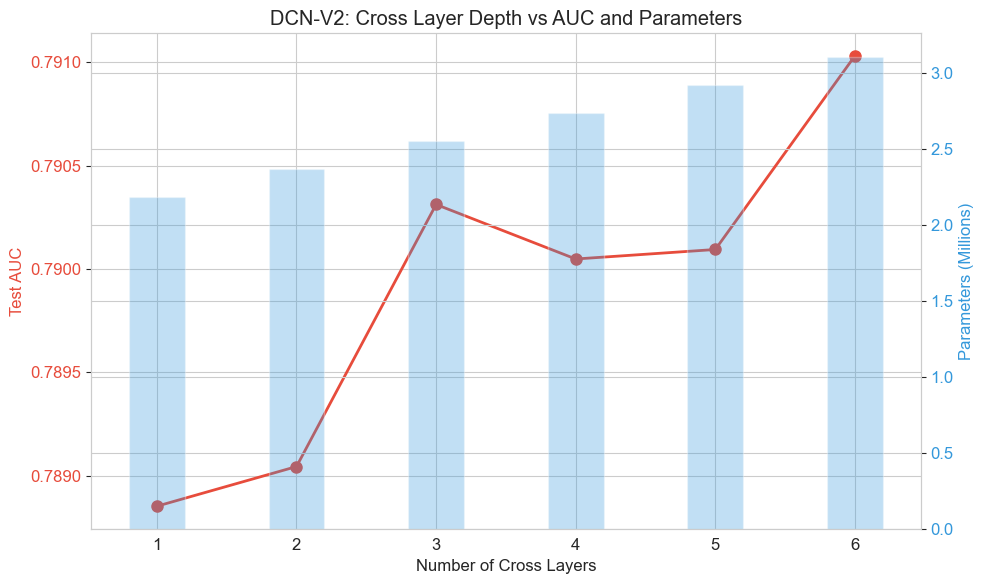

In [12]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = '#e74c3c'
ax1.plot(depth_df['cross_layers'], depth_df['auc'], 'o-', color=color1,
         linewidth=2, markersize=8, label='AUC')
ax1.set_xlabel('Number of Cross Layers')
ax1.set_ylabel('Test AUC', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(depth_df['cross_layers'])

ax2 = ax1.twinx()
color2 = '#3498db'
ax2.bar(depth_df['cross_layers'], depth_df['params'] / 1e6, alpha=0.3,
        color=color2, width=0.4, label='Params (M)')
ax2.set_ylabel('Parameters (Millions)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_title('DCN-V2: Cross Layer Depth vs AUC and Parameters')
fig.tight_layout()
plt.savefig('dcn_depth_study.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Stacked vs Parallel Comparison

In [13]:
structure_results = []

for struct in ['parallel', 'stacked']:
    print(f'\n--- Structure: {struct} ---')
    
    model_struct = DCN(
        num_num_features=len(NUM_FEATURES),
        cat_cardinalities=cat_cardinalities,
        embedding_dim=EMBEDDING_DIM,
        cross_num_layers=CROSS_LAYERS,
        hidden_dims=HIDDEN_DIMS,
        dropout=DROPOUT,
        cross_version='v2',
        structure=struct
    ).to(device)
    
    res = train_model(
        model_struct, train_loader, test_loader, device,
        num_epochs=10, lr=1e-3, weight_decay=1e-5, patience=3,
        model_name=f'dcn_v2_{struct}'
    )
    
    structure_results.append({
        'structure': struct,
        'auc': res['best_auc'],
        'logloss': res['best_logloss'],
        'params': sum(p.numel() for p in model_struct.parameters()),
        'time': res['training_time']
    })

struct_df = pd.DataFrame(structure_results)
print('\nStacked vs Parallel Results:')
print(struct_df.to_string(index=False))


--- Structure: parallel ---
Training dcn_v2_parallel for up to 10 epochs (patience=3)
--------------------------------------------------------------------------------


Epoch  1/10 | Train Loss: 0.4790 | Test AUC: 0.7882 | Test LogLoss: 0.4598 | Time: 47.7s
  -> New best AUC! Model saved.


Epoch  2/10 | Train Loss: 0.4479 | Test AUC: 0.7896 | Test LogLoss: 0.4583 | Time: 57.3s
  -> New best AUC! Model saved.


Epoch  3/10 | Train Loss: 0.4349 | Test AUC: 0.7882 | Test LogLoss: 0.4604 | Time: 57.0s


Epoch  4/10 | Train Loss: 0.4184 | Test AUC: 0.7835 | Test LogLoss: 0.4683 | Time: 58.0s


...

Epoch  2/10 | Train Loss: 0.4574 | Test AUC: 0.7869 | Test LogLoss: 0.4634 | Time: 46.0s
  -> New best AUC! Model saved.


Epoch  3/10 | Train Loss: 0.4401 | Test AUC: 0.7855 | Test LogLoss: 0.4635 | Time: 56.7s


Epoch  4/10 | Train Loss: 0.4240 | Test AUC: 0.7791 | Test LogLoss: 0.4762 | Time: 55.9s


Epoch  5/10 | Train Loss: 0.3922 | Test AUC: 0.7681 | Test LogLoss: 0.5006 | Time: 56.6s

Early stopping at epoch 5.



Best AUC: 0.7869 | LogLoss: 0.4634 | Time: 262.5s

Stacked vs Parallel Results:
structure      auc  logloss  params       time
 parallel 0.789585 0.458253 2550192 276.910226
  stacked 0.786887 0.463430 2549763 262.542081


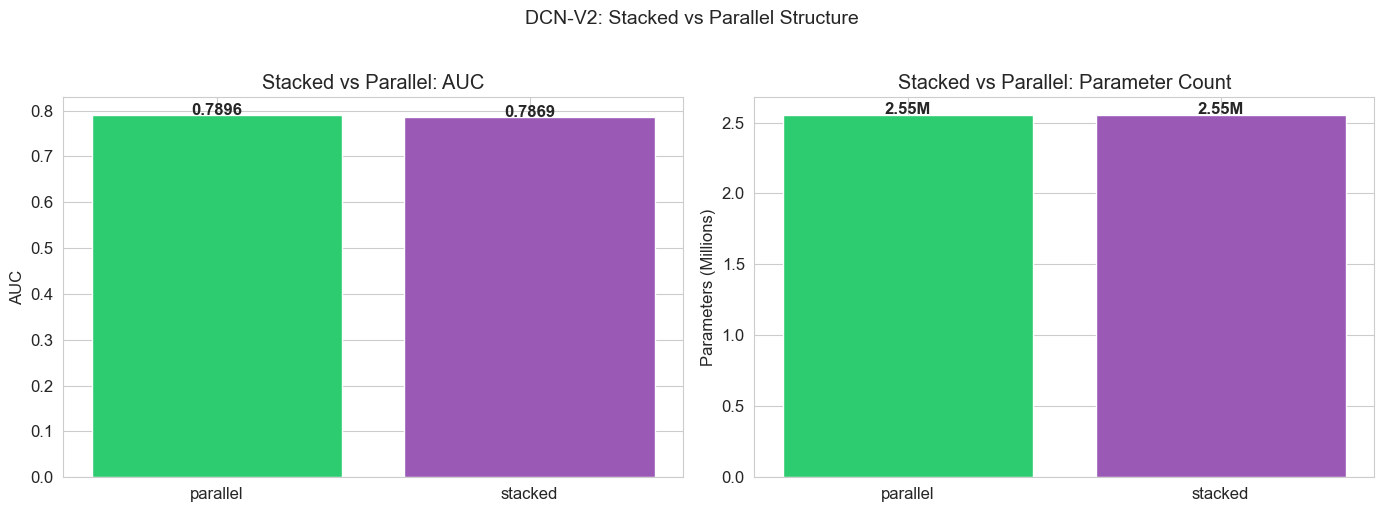

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#9b59b6']

axes[0].bar(struct_df['structure'], struct_df['auc'], color=colors)
axes[0].set_ylabel('AUC')
axes[0].set_title('Stacked vs Parallel: AUC')
for i, row in struct_df.iterrows():
    axes[0].text(i, row['auc'] + 0.0003, f'{row["auc"]:.4f}', ha='center', fontweight='bold')

axes[1].bar(struct_df['structure'], struct_df['params'] / 1e6, color=colors)
axes[1].set_ylabel('Parameters (Millions)')
axes[1].set_title('Stacked vs Parallel: Parameter Count')
for i, row in struct_df.iterrows():
    axes[1].text(i, row['params']/1e6 + 0.01, f'{row["params"]/1e6:.2f}M', ha='center', fontweight='bold')

plt.suptitle('DCN-V2: Stacked vs Parallel Structure', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('dcn_stacked_vs_parallel.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.4 Parameter Efficiency Comparison

In [15]:
# Parameter count comparison table
param_data = [
    {'Model': 'DCN-V1', 'AUC': v1_results['best_auc'],
     'LogLoss': v1_results['best_logloss'],
     'Parameters': v1_results['total_params'],
     'Training Time (s)': v1_results['training_time']},
    {'Model': 'DCN-V2', 'AUC': v2_results['best_auc'],
     'LogLoss': v2_results['best_logloss'],
     'Parameters': v2_results['total_params'],
     'Training Time (s)': v2_results['training_time']},
    {'Model': f'DCN-V2 (LR={LOW_RANK})', 'AUC': v2_lr_results['best_auc'],
     'LogLoss': v2_lr_results['best_logloss'],
     'Parameters': v2_lr_results['total_params'],
     'Training Time (s)': v2_lr_results['training_time']},
]

param_df = pd.DataFrame(param_data)
param_df['AUC/M Params'] = param_df['AUC'] / (param_df['Parameters'] / 1e6)

print('Parameter Efficiency Comparison:')
print(param_df.to_string(index=False))

Parameter Efficiency Comparison:
          Model      AUC  LogLoss  Parameters  Training Time (s)  AUC/M Params
         DCN-V1 0.788189 0.459728     1999356         122.129312      0.394222
         DCN-V2 0.789563 0.458563     2550192         164.792023      0.309609
DCN-V2 (LR=107) 0.789317 0.459089     2273487         146.619138      0.347183


> **Common Pitfall:** DCN-V2 with full-rank weight matrices can have significantly more
> parameters than DCN-V1, especially when the input dimension is large. The low-rank
> approximation provides a good balance between expressiveness and parameter efficiency.
> Always compare AUC-per-parameter, not just raw AUC.

## 9. Exercises

### Exercise 1: Implement MoE (Mixture of Experts) Cross Layer

DCN-V2 paper suggests using mixture of experts for the cross layer. Implement a cross layer where $W_l = \sum_{k=1}^K g_k(x_l) W_l^k$ with gating $g(x_l) = \text{softmax}(W_g x_l)$.

In [16]:
# TODO: Exercise 1
# 1. Implement MoECrossLayer with K expert weight matrices
# 2. Implement a gating network that produces expert weights
# 3. Replace the standard V2 cross layer with MoE
# 4. Train and compare with standard DCN-V2

# Your code here:
pass

### Exercise 2: Visualize Cross Layer Weights

Extract the weight matrices from each cross layer and visualize them as heatmaps. Do deeper layers show different patterns?

In [17]:
# TODO: Exercise 2
# 1. Extract weight matrices from each cross layer of the trained DCN-V2
# 2. Plot as heatmaps (subsample if too large)
# 3. Compute and plot the singular value spectrum of each weight matrix
# 4. Discuss: what does the effective rank tell us?

# Your code here:
pass

### Exercise 3: DCN with Different DNN Architectures

Try different DNN architectures: [128, 64], [512, 256, 128], [256, 256, 256]. How does the DNN depth/width interact with the cross network?

In [18]:
# TODO: Exercise 3
# 1. Train DCN-V2 with each DNN architecture
# 2. Record AUC, parameter count, and training time
# 3. Plot a Pareto frontier of AUC vs parameters
# 4. What is the most efficient configuration?

# Your code here:
pass

### Exercise 4: Low-Rank Sensitivity Analysis

Test different low-rank values: [d//8, d//4, d//2, d]. Plot AUC vs rank and parameter count vs rank.

In [19]:
# TODO: Exercise 4
# 1. Compute input_dim for your model
# 2. Test ranks: [d//8, d//4, d//2, d]
# 3. Train DCN-V2 with each rank
# 4. Plot AUC vs rank and parameters vs rank on dual-axis chart

# Your code here:
pass

## 10. Summary & Key Takeaways

In [20]:
print('=' * 70)
print('DCN Results Summary')
print('=' * 70)
print(f'{"Model":<25} {"AUC":>8} {"LogLoss":>10} {"Params":>12} {"Time (s)":>10}')
print('-' * 70)
print(f'{"DCN-V1 (parallel)":<25} {v1_results["best_auc"]:>8.4f} '
      f'{v1_results["best_logloss"]:>10.4f} {v1_results["total_params"]:>12,} '
      f'{v1_results["training_time"]:>10.1f}')
print(f'{"DCN-V2 (parallel)":<25} {v2_results["best_auc"]:>8.4f} '
      f'{v2_results["best_logloss"]:>10.4f} {v2_results["total_params"]:>12,} '
      f'{v2_results["training_time"]:>10.1f}')
print(f'{"DCN-V2 (low-rank)":<25} {v2_lr_results["best_auc"]:>8.4f} '
      f'{v2_lr_results["best_logloss"]:>10.4f} {v2_lr_results["total_params"]:>12,} '
      f'{v2_lr_results["training_time"]:>10.1f}')
print('=' * 70)

# Save results for comparison notebook
dcn_results = {
    'dcn_v1': v1_results,
    'dcn_v2': v2_results,
    'dcn_v2_lowrank': v2_lr_results,
    'depth_study': depth_df.to_dict(),
    'structure_study': struct_df.to_dict(),
    'config': {
        'embedding_dim': EMBEDDING_DIM,
        'cross_layers': CROSS_LAYERS,
        'hidden_dims': HIDDEN_DIMS,
        'dropout': DROPOUT,
        'low_rank': LOW_RANK
    }
}

with open(os.path.join(MODEL_DIR, 'dcn_results.pkl'), 'wb') as f:
    pickle.dump(dcn_results, f)

print(f'\nResults saved to {MODEL_DIR}/dcn_results.pkl')

DCN Results Summary
Model                          AUC    LogLoss       Params   Time (s)
----------------------------------------------------------------------
DCN-V1 (parallel)           0.7882     0.4597    1,999,356      122.1
DCN-V2 (parallel)           0.7896     0.4586    2,550,192      164.8
DCN-V2 (low-rank)           0.7893     0.4591    2,273,487      146.6

Results saved to ./saved_models/dcn_results.pkl


### Key Takeaways

1. **Cross Layer Efficiency:** DCN-V1's cross layers add only $O(d)$ parameters per layer,
   making them extremely parameter-efficient for modeling explicit feature interactions.

2. **V2 Expressiveness:** DCN-V2 with full-rank weight matrices can model more complex
   interactions than V1, at the cost of $O(d^2)$ parameters per layer. The low-rank
   approximation provides a practical middle ground.

3. **Cross Layer Depth:** Performance generally improves with more cross layers up to a
   point, after which returns diminish or overfitting occurs. 3 layers is a common sweet spot.

4. **Parallel vs Stacked:** The parallel structure typically outperforms stacked because it
   allows the cross and deep components to specialize independently.

5. **Residual Connections:** The residual connection in cross layers ($+\mathbf{x}_l$) is
   critical for training stability, ensuring that each layer can learn incremental improvements.

### Next Steps

In the next notebook, we will bring together DeepFM, DCN-V1, and DCN-V2 for a comprehensive
head-to-head comparison, including statistical significance tests and deployment considerations.